# Koopman Spectral Clustering

Recover **dynamically coherent** node groups from leading Koopman eigenmodes
(`koopman_spectral_clustering`), quantify agreement with planted labels via
**adjusted Rand index (ARI)**, and compare against classical Laplacian
spectral clustering (Ng, Jordan & Weiss — `Ng2002SpectralClustering`;
von Luxburg — `VonLuxburg2007`).

Cross-links: spectrum vocabulary in
[`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb); spectrum-*distance*
clustering / anomalies in
[`16_spectral_similarity_anomalies.ipynb`](16_spectral_similarity_anomalies.ipynb)
(different axis — trajectories / regimes, not node communities).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

from koopman_graph.analysis import koopman_spectral_clustering
from koopman_graph.datasets.topology import ring_edge_index
from koopman_graph.graph_utils import dense_symmetric_normalized_adjacency
from koopman_graph.model import GraphKoopmanModel
from koopman_graph.nn import GNNDecoder, GNNEncoder
from koopman_graph.operators import GraphKoopmanOperator
from koopman_graph.spectrum_types import compute_spectrum

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 36
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

N_PER = 4 if IS_TEST else 6
print(f"IS_TEST={IS_TEST}  N_PER={N_PER}")


IS_TEST=False  N_PER=6


## Motivation and background

Static Laplacian spectral clustering embeds nodes from the graph Laplacian
and runs k-means (Ng et al., 2002; von Luxburg, 2007). Koopman spectral
clustering embeds from **leading eigenmodes of a dynamical operator** (or its
networked effective map), then k-means — communities reflect *dynamics*, not
topology alone.

When the dynamical map inherits the adjacency cut, both agree. When community
structure lives in the operator but not the contact graph, static methods can
miss it.


## Helpers: ARI, planted graph, Laplacian baseline


In [2]:
def adjusted_rand_index(labels_true: torch.Tensor, labels_pred: torch.Tensor) -> float:
    """Adjusted Rand index in [-1, 1] (1 = perfect agreement)."""
    y = labels_true.to(torch.long).reshape(-1)
    pred = labels_pred.to(torch.long).reshape(-1)
    n = y.numel()
    if n < 2:
        return 1.0

    def _contingency(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
        table = torch.zeros(int(a.max()) + 1, int(b.max()) + 1, dtype=torch.float64)
        for i in range(n):
            table[int(a[i]), int(b[i])] += 1.0
        return table

    table = _contingency(y, pred)
    sum_comb_c = torch.sum(table * (table - 1) / 2).item()
    a_rows, b_cols = table.sum(dim=1), table.sum(dim=0)
    sum_comb_a = torch.sum(a_rows * (a_rows - 1) / 2).item()
    sum_comb_b = torch.sum(b_cols * (b_cols - 1) / 2).item()
    comb_n = n * (n - 1) / 2.0
    expected = sum_comb_a * sum_comb_b / comb_n if comb_n else 0.0
    max_index = 0.5 * (sum_comb_a + sum_comb_b)
    denom = max_index - expected
    if abs(denom) < 1e-12:
        return 1.0
    return float((sum_comb_c - expected) / denom)


def two_community_edge_index(n_per: int = 6):
    """Two cliques + one bridge; return edge_index and planted labels."""
    edges: list[list[int]] = []
    for offset in (0, n_per):
        nodes = list(range(offset, offset + n_per))
        for i, src in enumerate(nodes):
            for dst in nodes[i + 1 :]:
                edges.extend([[src, dst], [dst, src]])
    edges.extend([[n_per - 1, n_per], [n_per, n_per - 1]])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    labels = torch.tensor([0] * n_per + [1] * n_per, dtype=torch.long)
    return edge_index, labels


def laplacian_spectral_clustering(
    edge_index: torch.Tensor,
    num_nodes: int,
    n_clusters: int = 2,
    *,
    seed: int = 0,
) -> torch.Tensor:
    """Fiedler-style clustering on the symmetric normalized Laplacian.

    For ``n_clusters=2``, embeds with the first nontrivial eigenvector (the
    Fiedler vector; von Luxburg, 2007) and runs the same seeded k-means path
    as ``koopman_spectral_clustering``. Zero-pads to ``n_clusters`` columns
    only to satisfy that API's ``n_modes`` contract.

    This is *not* the full Ng–Jordan–Weiss procedure (``k`` eigenvectors with
    row normalization).
    """
    adj = dense_symmetric_normalized_adjacency(
        edge_index, num_nodes, dtype=torch.float64
    )
    # Symmetric normalized Laplacian L = I - Â
    lap = torch.eye(num_nodes, dtype=torch.float64) - adj
    _evals, evecs = torch.linalg.eigh(lap)
    # Smallest non-trivial eigenvectors (skip near-zero trivial mode).
    n_fiedler = max(1, n_clusters - 1)
    emb = evecs[:, 1 : 1 + n_fiedler].real.to(torch.float32)
    # Dummy spectrum from Â so the shared clustering API can run k-means.
    spectrum = compute_spectrum(adj.to(torch.float32), time_step=1.0)
    if emb.shape[1] < n_clusters:
        pad = torch.zeros(num_nodes, n_clusters - emb.shape[1])
        modes = torch.cat([emb, pad], dim=1)
    else:
        modes = emb[:, :n_clusters]
    result = koopman_spectral_clustering(
        spectrum, n_clusters, n_modes=n_clusters, modes=modes, seed=seed
    )
    return result.labels


## Minimal example: planted two-community adjacency map

Treat the **symmetric normalized adjacency** \(\hat{A}\) as a discrete linear
map on node states — diffusion-*like*, but not the random-walk matrix
\(D^{-1}A\). Two cliques with a weak bridge: the graph cut and this map agree,
so Koopman clustering on \(\hat{A}\) and Laplacian clustering on the graph
both recover the planted labels.


In [3]:
edge_index, planted = two_community_edge_index(N_PER)
num_nodes = int(planted.numel())
adj = dense_symmetric_normalized_adjacency(
    edge_index, num_nodes, dtype=torch.float32
)
spectrum = compute_spectrum(adj, time_step=1.0)
modes = spectrum.eigenvectors[:, :2].real

koop_result = koopman_spectral_clustering(
    spectrum, n_clusters=2, n_modes=2, modes=modes, seed=SEED
)
lap_labels = laplacian_spectral_clustering(
    edge_index, num_nodes, n_clusters=2, seed=SEED
)

ari_koop = adjusted_rand_index(planted, koop_result.labels)
ari_lap = adjusted_rand_index(planted, lap_labels)
print(f"Planted two-community (N={num_nodes})")
print(f"  Koopman spectral clustering ARI: {ari_koop:.3f}")
print(f"  Laplacian spectral clustering ARI: {ari_lap:.3f}")
print(f"  Koopman labels: {koop_result.labels.tolist()}")
print(f"  Planted:        {planted.tolist()}")


Planted two-community (N=12)
  Koopman spectral clustering ARI: 1.000
  Laplacian spectral clustering ARI: 1.000
  Koopman labels: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
  Planted:        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


## Progressive deep dive: networked model path

Same planted topology through `GraphKoopmanModel` + `koopman="graph"`
(effective \(N\cdot d\) eigenvectors → per-node embedding).


In [4]:
torch.manual_seed(SEED)
model = GraphKoopmanModel(
    encoder=GNNEncoder(1, 8, 1, num_layers=1),
    decoder=GNNDecoder(1, 8, 1, num_layers=1),
    latent_dim=1,
    time_step=0.1,
    koopman="graph",
)
assert isinstance(model.koopman, GraphKoopmanOperator)
model.koopman.set_dense_matrices(
    torch.tensor([[0.55]]),
    torch.tensor([[0.4]]),
)
model_result = koopman_spectral_clustering(
    model,
    n_clusters=2,
    n_modes=2,
    edge_index=edge_index,
    num_nodes=num_nodes,
    seed=SEED,
)
ari_model = adjusted_rand_index(planted, model_result.labels)
print(f"GraphKoopmanModel path ARI: {ari_model:.3f}")
print(f"  labels: {model_result.labels.tolist()}")


GraphKoopmanModel path ARI: 1.000
  labels: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


## When static topology misses dynamics

Ring contact graph (no planted cut) vs a **block-structured dynamical map**
with two communities. Laplacian clustering on the ring cannot recover the
planted labels; Koopman clustering on the dynamical spectrum can.


In [5]:
# Static topology: ring (no community cut).
ring = ring_edge_index(num_nodes)
ring_lap_labels = laplacian_spectral_clustering(
    ring, num_nodes, n_clusters=2, seed=SEED
)
ari_ring_lap = adjusted_rand_index(planted, ring_lap_labels)

# Dynamical map: strong within-community coupling, weak cross terms.
torch.manual_seed(SEED)
k_dyn = 0.05 * torch.randn(num_nodes, num_nodes)
for i in range(N_PER):
    for j in range(N_PER):
        k_dyn[i, j] = 0.8 if i == j else 0.15
        k_dyn[i + N_PER, j + N_PER] = 0.75 if i == j else 0.12
# Tiny leakage across communities.
k_dyn[N_PER - 1, N_PER] = 0.02
k_dyn[N_PER, N_PER - 1] = 0.02
# Row-normalize toward a stable discrete map.
k_dyn = k_dyn / k_dyn.abs().sum(dim=1, keepdim=True).clamp_min(1e-6) * 0.9

dyn_spectrum = compute_spectrum(k_dyn, time_step=1.0)
dyn_modes = dyn_spectrum.eigenvectors[:, :2].real
dyn_result = koopman_spectral_clustering(
    dyn_spectrum, n_clusters=2, n_modes=2, modes=dyn_modes, seed=SEED
)
ari_dyn_koop = adjusted_rand_index(planted, dyn_result.labels)

print("Dynamic communities / ring topology:")
print(f"  Laplacian on ring ARI:              {ari_ring_lap:.3f}")
print(f"  Koopman on dynamical map ARI:       {ari_dyn_koop:.3f}")
if ari_dyn_koop > ari_ring_lap + 0.2 and ari_dyn_koop >= 0.5:
    print(
        "Demonstrated: Koopman recovers dynamically planted groups that "
        "static ring Laplacian clustering misses."
    )
else:
    print(
        "Honest non-claim: on this seed the dynamic-vs-static gap is weak "
        f"(Koopman ARI={ari_dyn_koop:.3f}, ring Laplacian ARI={ari_ring_lap:.3f})."
    )


Dynamic communities / ring topology:
  Laplacian on ring ARI:              -0.066
  Koopman on dynamical map ARI:       1.000
Demonstrated: Koopman recovers dynamically planted groups that static ring Laplacian clustering misses.


## Results

Left: **Scenario A** — when the cut lives in both the graph and the
adjacency map, Koopman on \(\hat{A}\), Laplacian on the graph, and the
networked model path all reach ARI \(= 1.0\) versus planted labels.

Center: **Scenario B** — Laplacian clustering on a ring (no planted cut) stays
near chance (ARI can be slightly negative); Koopman clustering on the block
dynamical map recovers the planted communities.

Right: Koopman embedding for Scenario A, colored by planted label. Separation
is along **mode 1**. Clique symmetry maps many nodes to the same coordinates,
so \(N\) nodes appear as a few overplotted markers (unique-coordinate count is
printed below the figure).


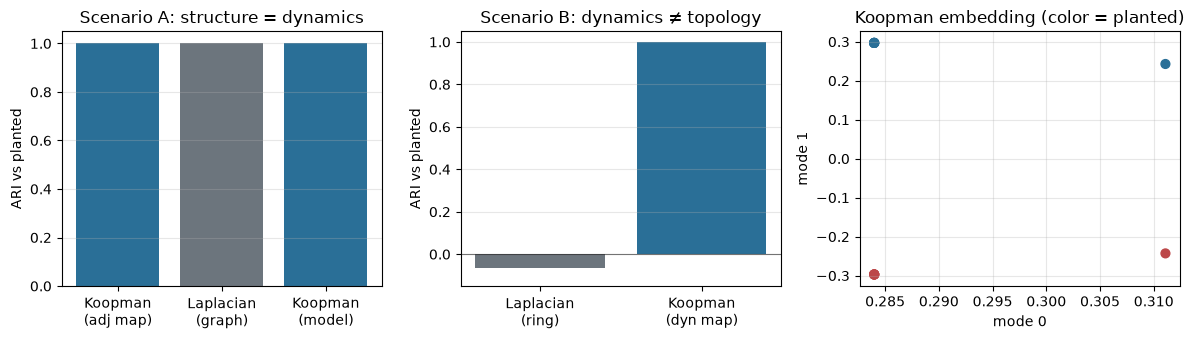

Summary A — Koopman ARI=1.000, Laplacian ARI=1.000, model ARI=1.000
Summary B — ring Laplacian ARI=-0.066, dyn Koopman ARI=1.000
Embedding overplot: 12 nodes → 4 unique coordinates (clique symmetry).


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Scenario A bars
names_a = ["Koopman\n(adj map)", "Laplacian\n(graph)", "Koopman\n(model)"]
vals_a = [ari_koop, ari_lap, ari_model]
axes[0].bar(names_a, vals_a, color=["#2a6f97", "#6c757d", "#2a6f97"])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("ARI vs planted")
axes[0].set_title("Scenario A: structure = dynamics")
axes[0].grid(axis="y", alpha=0.3)

# Scenario B bars (ARI may be slightly negative)
names_b = ["Laplacian\n(ring)", "Koopman\n(dyn map)"]
vals_b = [ari_ring_lap, ari_dyn_koop]
axes[1].bar(names_b, vals_b, color=["#6c757d", "#2a6f97"])
ymin = min(-0.15, min(vals_b) - 0.05)
axes[1].set_ylim(ymin, 1.05)
axes[1].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("ARI vs planted")
axes[1].set_title("Scenario B: dynamics ≠ topology")
axes[1].grid(axis="y", alpha=0.3)

# Embedding scatter for planted case (overplot under clique symmetry)
emb = koop_result.embedding.detach().cpu().numpy()
colors = ["#2a6f97" if int(c) == 0 else "#bc4749" for c in planted.tolist()]
axes[2].scatter(emb[:, 0], emb[:, 1], c=colors, s=40)
axes[2].set_xlabel("mode 0")
axes[2].set_ylabel("mode 1")
axes[2].set_title("Koopman embedding (color = planted)")
axes[2].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

n_unique = int(np.unique(np.round(emb, decimals=5), axis=0).shape[0])
print(
    f"Summary A — Koopman ARI={ari_koop:.3f}, Laplacian ARI={ari_lap:.3f}, "
    f"model ARI={ari_model:.3f}"
)
print(
    f"Summary B — ring Laplacian ARI={ari_ring_lap:.3f}, "
    f"dyn Koopman ARI={ari_dyn_koop:.3f}"
)
print(
    f"Embedding overplot: {num_nodes} nodes → {n_unique} unique coordinates "
    "(clique symmetry)."
)


## Interpretation

- On the planted two-clique adjacency map, Koopman and Laplacian both recover
  communities — the discrete map inherits the cut.
- On the ring + block dynamical map, topology alone is insufficient; cluster
  quality tracks the **operator** you supply (classical spectral clustering
  when that operator is the graph Laplacian).
- Poor operators ⇒ poor clusters (API warning). Notebook 07 for spectrum
  diagnostics; notebook 16 for clustering *trajectories* by spectral distance.


## Takeaways

- Call `koopman_spectral_clustering(source, n_clusters=..., edge_index=...)`
  for networked models, or pass `modes=` with a bare spectrum.
- Quantify with ARI against planted labels; compare Laplacian when topology
  is the hypothesized cut.
- Claim “dynamics beat static topology” only when Scenario B (or similar)
  shows a clear ARI gap.
- Citations: `Ng2002SpectralClustering`, `VonLuxburg2007`.


## Further reading

- API: `koopman_graph.analysis.koopman_spectral_clustering`, `ClusteringResult`
- Related notebooks:
  [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb),
  [`16_spectral_similarity_anomalies.ipynb`](16_spectral_similarity_anomalies.ipynb)
- Citations (`paper.bib`): `Ng2002SpectralClustering`, `VonLuxburg2007`
